# AP2 — Amostragem
**Processamento de Sinais I** — Prof. Rafael S. Chaves

Resolução das questões da Atividade Prática 2: amostragem, análise
espectral, subamostragem, sobreamostragem e reconstrução de sinais.

> Rode as células na ordem. As Questões 4–7 e 9–10 dependem de
> `handel.wav`, `h_banheiro.wav` e `sinal_taca.wav` lidos na Questão 3
> e na célula de leitura da Questão 9.


## Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import chirp as scipy_chirp, fftconvolve, resample, resample_poly
from math import gcd
from IPython.display import Audio, display
import os

PASTA_DADOS = "dados"

In [ ]:
def gerar_cosseno(f, duracao, fs):
    """Gera x(t) = cos(2*pi*f*t)."""
    t = np.arange(0, duracao, 1 / fs)
    return t, np.cos(2 * np.pi * f * t)


def gerar_chirp(f0, f1, duracao, fs, metodo="linear"):
    """Gera um chirp entre f0 e f1 (metodo: 'linear', 'quadratic' ou 'logarithmic')."""
    t = np.arange(0, duracao, 1 / fs)
    return t, scipy_chirp(t, f0=f0, f1=f1, t1=duracao, method=metodo)


def ler_wav(nome_arquivo):
    """Lê um .wav da pasta PASTA_DADOS e normaliza para [-1, 1]."""
    fs, x = wavfile.read(os.path.join(PASTA_DADOS, nome_arquivo))
    if x.ndim > 1:
        x = x[:, 0]
    if np.issubdtype(x.dtype, np.integer):
        x = x.astype(np.float64) / np.iinfo(x.dtype).max
    else:
        x = x.astype(np.float64)
    return fs, x


def tocar(x, fs):
    """Reproduz um sinal de áudio inline (player do notebook)."""
    display(Audio(x, rate=fs))


def plotar_tempo(t, x, titulo, xlim=None, xlabel="Tempo (s)"):
    plt.figure(figsize=(7, 3.5))
    plt.plot(t, x, linewidth=0.8)
    plt.xlabel(xlabel)
    plt.ylabel("Amplitude")
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    if xlim is not None:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()

In [ ]:
def calculate_spectrum(x, fs, titulo="Espectro", xlim=None, escala_db=True):
    """Calcula e plota o espectro de magnitude (via FFT) de um sinal real x,
    amostrado a fs Hz. Retorna (freqs, mag) para uso posterior, se necessário.
    """
    n = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    mag = np.abs(X) / n

    plt.figure(figsize=(7, 3.5))
    if escala_db:
        plt.plot(freqs, 20 * np.log10(mag + 1e-12), linewidth=0.8)
        plt.ylabel("Magnitude (dB)")
    else:
        plt.plot(freqs, mag, linewidth=0.8)
        plt.ylabel("Magnitude")
    plt.xlabel("Frequência (Hz)")
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    if xlim is not None:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()

    return freqs, mag

In [ ]:
FS = 44100     # Hz — fs usada nas Questões 1-7
DURACAO = 1    # s — duração usada para o cálculo dos espectros

## Questão 1 — Espectro de sinais cossenoidais

x(t) = cos(2πft), fs = 44,1 kHz, f ∈ {500, 5000, 10000, 50000} Hz.

Observação: como fs/2 = 22050 Hz, a componente de 50000 Hz está acima
da frequência de Nyquist e sofre *aliasing* — sua imagem espectral
aparecerá refletida para dentro da banda [0, fs/2].


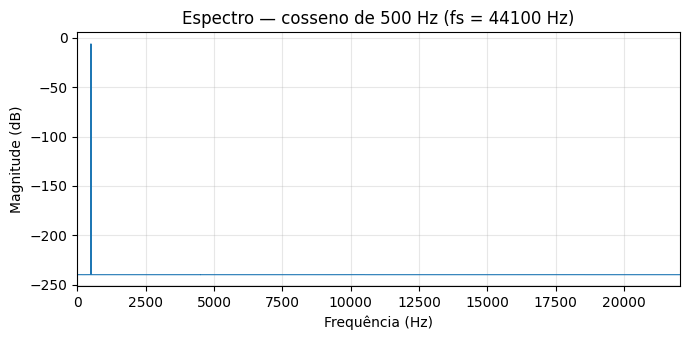

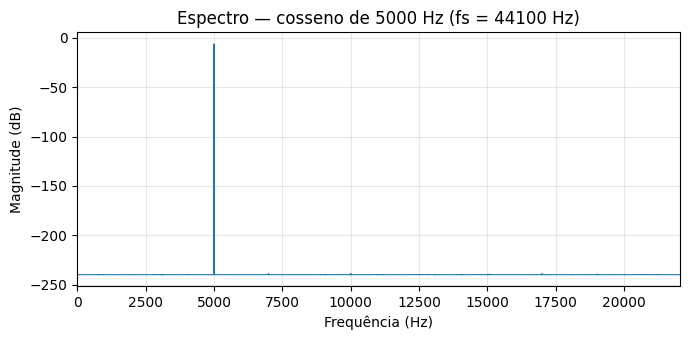

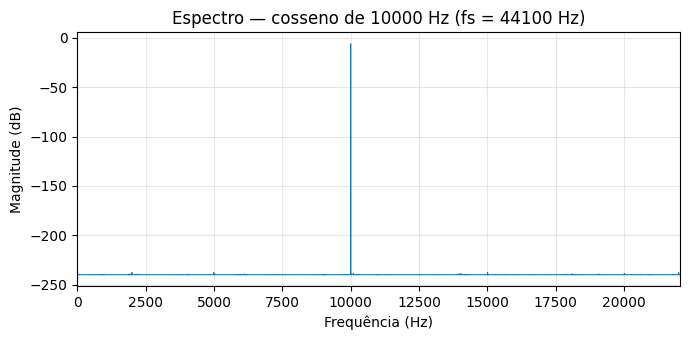

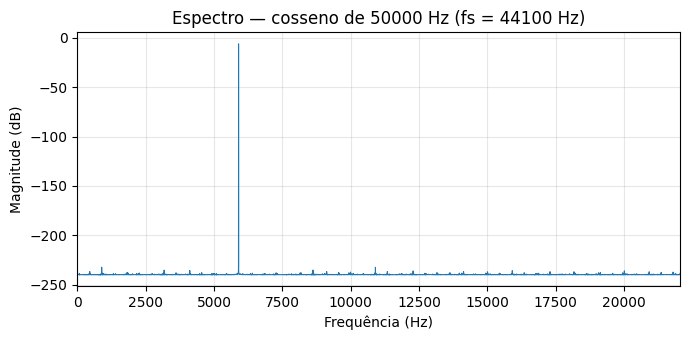

In [ ]:
frequencias_q1 = [500, 5000, 10000, 50000]

espectros_q1 = {}
for f in frequencias_q1:
    _, x = gerar_cosseno(f, DURACAO, FS)
    freqs, mag = calculate_spectrum(
        x, FS, titulo=f"Espectro — cosseno de {f} Hz (fs = {FS} Hz)", xlim=(0, FS / 2)
    )
    espectros_q1[f] = (freqs, mag)

## Questão 2 — Espectro de chirps

Chirp entre f0 = 500 Hz e f1 = 10000 Hz, fs = 44,1 kHz, varreduras
linear, quadrática e logarítmica.


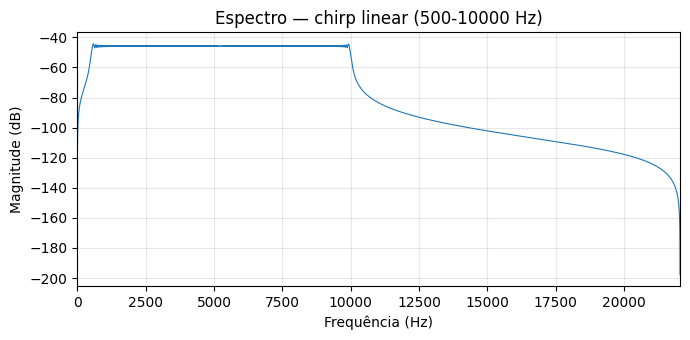

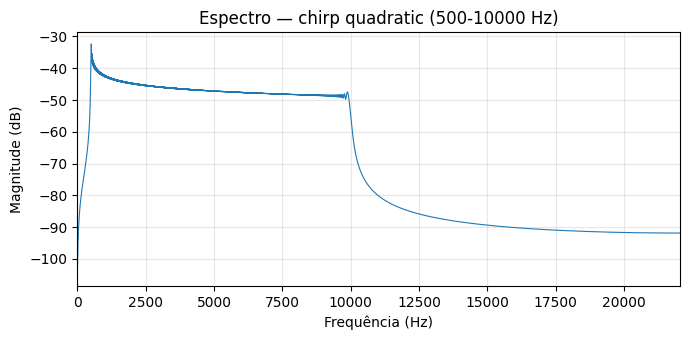

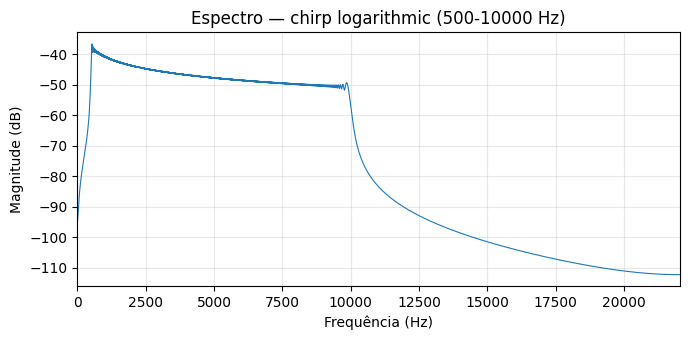

In [ ]:
F0, F1 = 500, 10000
METODOS_CHIRP = ["linear", "quadratic", "logarithmic"]

espectros_q2 = {}
for metodo in METODOS_CHIRP:
    _, x = gerar_chirp(F0, F1, DURACAO, FS, metodo=metodo)
    freqs, mag = calculate_spectrum(
        x, FS, titulo=f"Espectro — chirp {metodo} ({F0}-{F1} Hz)", xlim=(0, FS / 2)
    )
    espectros_q2[metodo] = (freqs, mag)

## Questão 3 — Espectro do sinal handel.wav


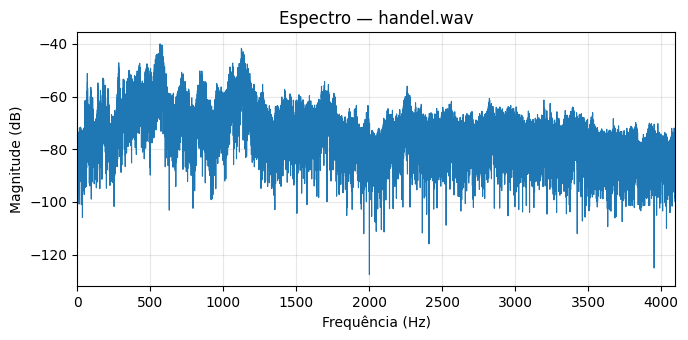

In [ ]:
fs_handel, x_handel = ler_wav("handel.wav")
freqs_handel, mag_handel = calculate_spectrum(
    x_handel, fs_handel, titulo="Espectro — handel.wav", xlim=(0, fs_handel / 2)
)

## Questão 4 — Subamostragem de handel.wav

Subamostrar x[n] por um fator M: y[n] = x[nM]. Para cada fator M, o
sinal subamostrado passa a representar a mesma duração real quando
reproduzido/analisado com fs_novo = fs/M.


In [ ]:
def subamostrar(x, M):
    """Subamostragem por fator M: y[n] = x[n*M]."""
    return x[::M]

In [ ]:
FATORES_M = [2, 4, 8]

sinais_subamostrados = {}
for M in FATORES_M:
    y = subamostrar(x_handel, M)
    fs_novo = fs_handel // M
    sinais_subamostrados[M] = (y, fs_novo)
    print(f"M = {M} -> fs_novo = {fs_novo} Hz, N = {len(y)} amostras")

M = 2 -> fs_novo = 4096 Hz, N = 36557 amostras
M = 4 -> fs_novo = 2048 Hz, N = 18279 amostras
M = 8 -> fs_novo = 1024 Hz, N = 9140 amostras


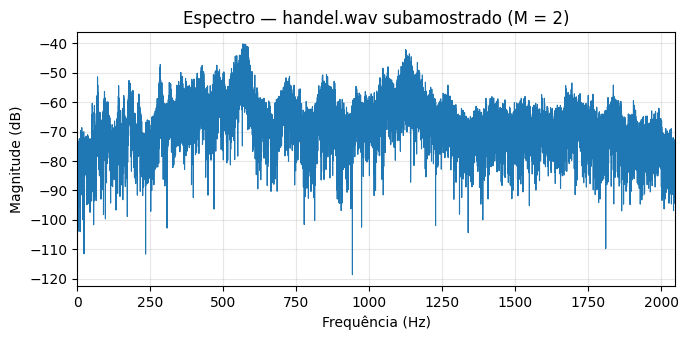

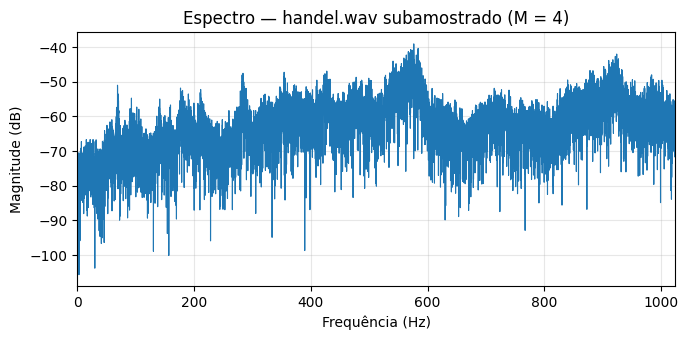

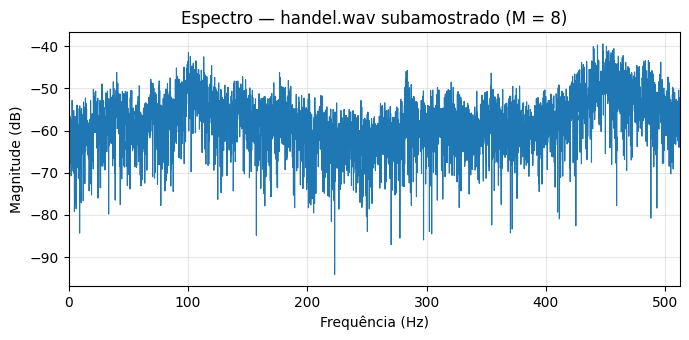

In [ ]:
# (c) espectro dos sinais subamostrados
for M, (y, fs_novo) in sinais_subamostrados.items():
    calculate_spectrum(
        y, fs_novo, titulo=f"Espectro — handel.wav subamostrado (M = {M})", xlim=(0, fs_novo / 2)
    )

In [ ]:
# (d) reprodução dos sinais subamostrados
for M, (y, fs_novo) in sinais_subamostrados.items():
    print(f"Sinal subamostrado por M = {M} (fs_novo = {fs_novo} Hz):")
    tocar(y, fs_novo)

Sinal subamostrado por M = 2 (fs_novo = 4096 Hz):


Sinal subamostrado por M = 4 (fs_novo = 2048 Hz):


Sinal subamostrado por M = 8 (fs_novo = 1024 Hz):


## Questão 5 — Subamostragem com scipy.signal.resample() e comparação


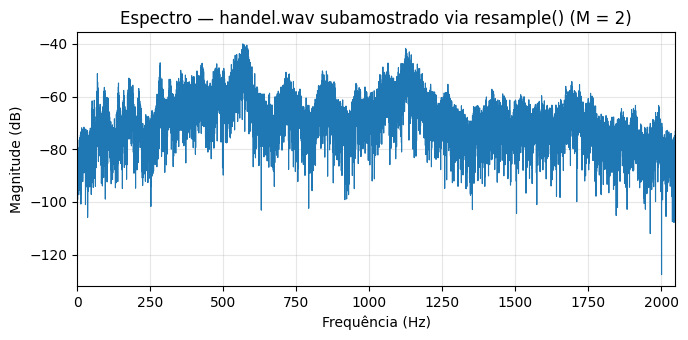

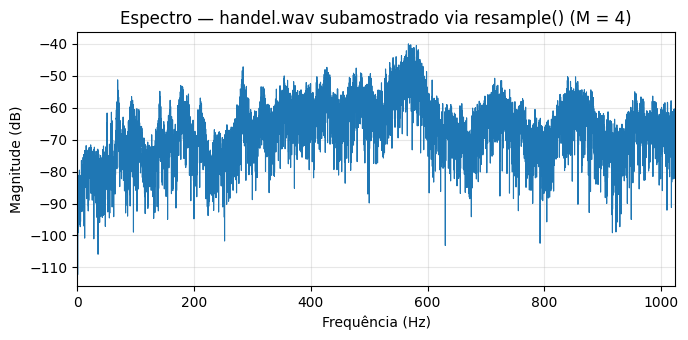

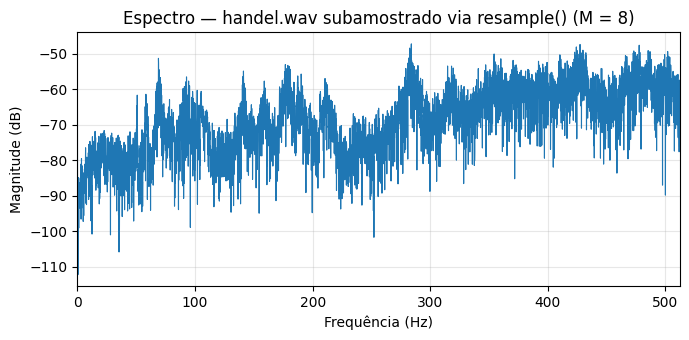

In [ ]:
sinais_subamostrados_resample = {}
for M in FATORES_M:
    num_amostras = len(x_handel) // M
    y_resample = resample(x_handel, num_amostras)
    fs_novo = fs_handel // M
    sinais_subamostrados_resample[M] = (y_resample, fs_novo)

    calculate_spectrum(
        y_resample, fs_novo,
        titulo=f"Espectro — handel.wav subamostrado via resample() (M = {M})",
        xlim=(0, fs_novo / 2),
    )

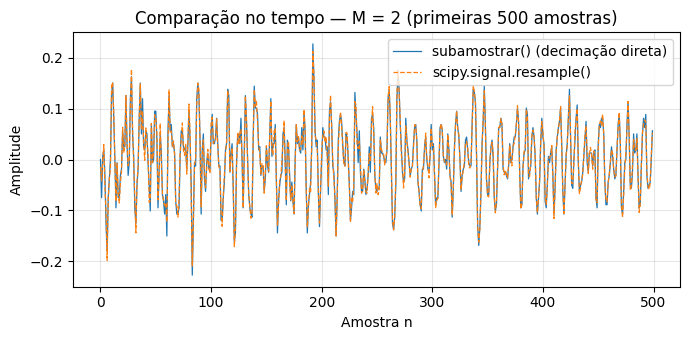

M = 2 — reproduzindo versão via resample():


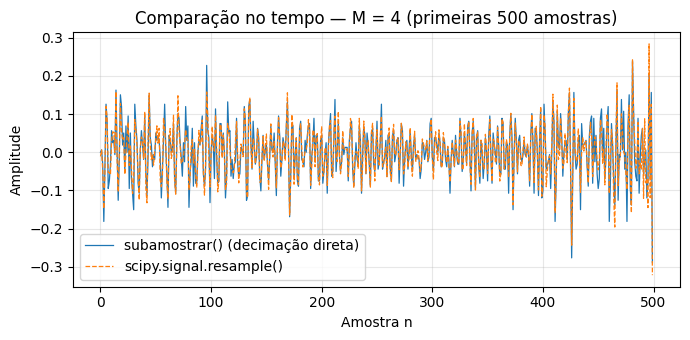

M = 4 — reproduzindo versão via resample():


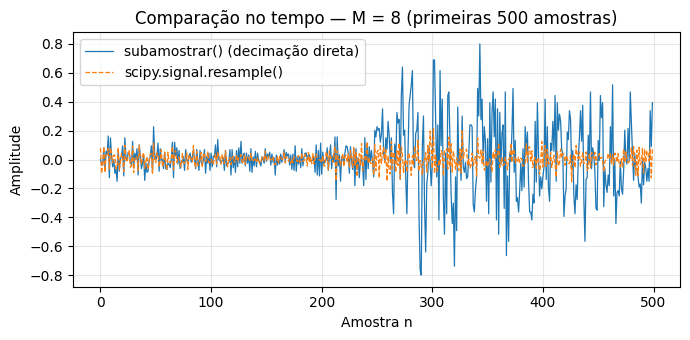

M = 8 — reproduzindo versão via resample():


In [ ]:
# Comparação no domínio do tempo: subamostragem própria (decimação direta)
# vs. scipy.signal.resample() (reamostragem via FFT / banda limitada)
for M in FATORES_M:
    y_proprio, fs_novo = sinais_subamostrados[M]
    y_resample, _ = sinais_subamostrados_resample[M]

    n_janela = min(len(y_proprio), len(y_resample), 500)
    plt.figure(figsize=(7, 3.5))
    plt.plot(y_proprio[:n_janela], label="subamostrar() (decimação direta)", linewidth=0.9)
    plt.plot(y_resample[:n_janela], label="scipy.signal.resample()", linewidth=0.9, linestyle="--")
    plt.xlabel("Amostra n")
    plt.ylabel("Amplitude")
    plt.title(f"Comparação no tempo — M = {M} (primeiras {n_janela} amostras)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"M = {M} — reproduzindo versão via resample():")
    tocar(y_resample, fs_novo)

## Questão 6 — Sobreamostragem de handel.wav

Sobreamostrar x[n] por um fator L: insere L−1 zeros entre cada duas
amostras. O sinal sobreamostrado passa a ter fs_novo = fs·L para
manter a mesma duração real.


In [ ]:
def sobreamostrar(x, L):
    """Sobreamostragem por fator L (inserção de zeros):
    y[n] = x[n/L] se n = m*L, m inteiro; y[n] = 0 caso contrário.
    """
    y = np.zeros(len(x) * L, dtype=x.dtype)
    y[::L] = x
    return y

In [ ]:
FATORES_L = [2, 4, 8]

sinais_sobreamostrados = {}
for L in FATORES_L:
    y = sobreamostrar(x_handel, L)
    fs_novo = fs_handel * L
    sinais_sobreamostrados[L] = (y, fs_novo)
    print(f"L = {L} -> fs_novo = {fs_novo} Hz, N = {len(y)} amostras")

L = 2 -> fs_novo = 16384 Hz, N = 146226 amostras
L = 4 -> fs_novo = 32768 Hz, N = 292452 amostras
L = 8 -> fs_novo = 65536 Hz, N = 584904 amostras


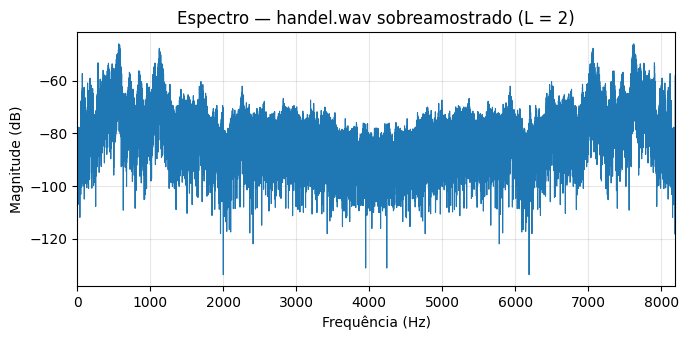

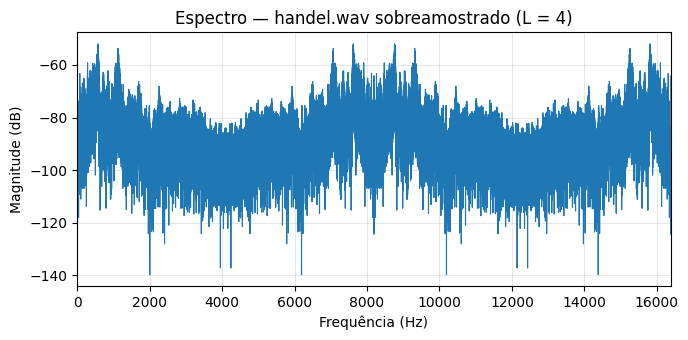

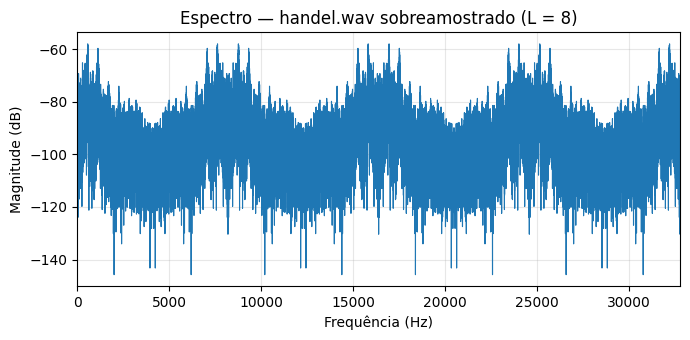

In [ ]:
# (c) espectro dos sinais sobreamostrados — observar as imagens espectrais
# periódicas introduzidas pela inserção de zeros (sem filtro de interpolação)
for L, (y, fs_novo) in sinais_sobreamostrados.items():
    calculate_spectrum(
        y, fs_novo, titulo=f"Espectro — handel.wav sobreamostrado (L = {L})", xlim=(0, fs_novo / 2)
    )

In [ ]:
# (d) reprodução dos sinais sobreamostrados
for L, (y, fs_novo) in sinais_sobreamostrados.items():
    print(f"Sinal sobreamostrado por L = {L} (fs_novo = {fs_novo} Hz):")
    tocar(y, fs_novo)

Sinal sobreamostrado por L = 2 (fs_novo = 16384 Hz):


Sinal sobreamostrado por L = 4 (fs_novo = 32768 Hz):


Sinal sobreamostrado por L = 8 (fs_novo = 65536 Hz):


## Questão 7 — Sobreamostragem com scipy.signal.resample() e comparação


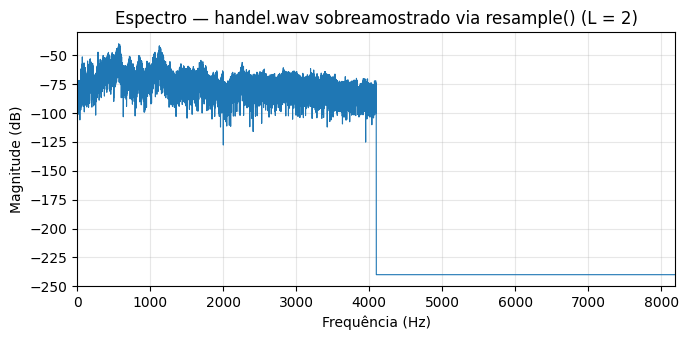

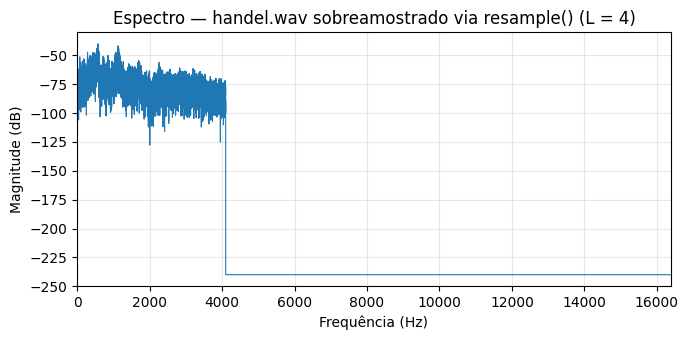

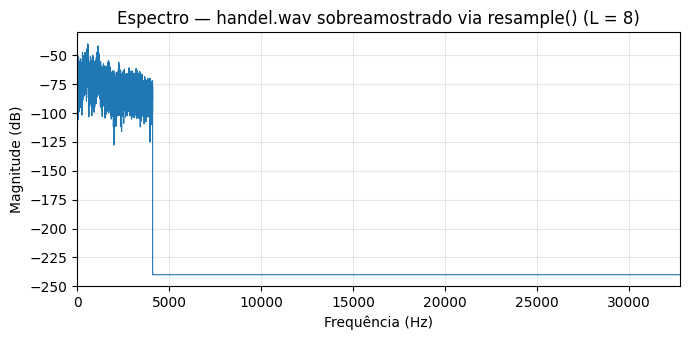

In [ ]:
sinais_sobreamostrados_resample = {}
for L in FATORES_L:
    num_amostras = len(x_handel) * L
    y_resample = resample(x_handel, num_amostras)
    fs_novo = fs_handel * L
    sinais_sobreamostrados_resample[L] = (y_resample, fs_novo)

    calculate_spectrum(
        y_resample, fs_novo,
        titulo=f"Espectro — handel.wav sobreamostrado via resample() (L = {L})",
        xlim=(0, fs_novo / 2),
    )

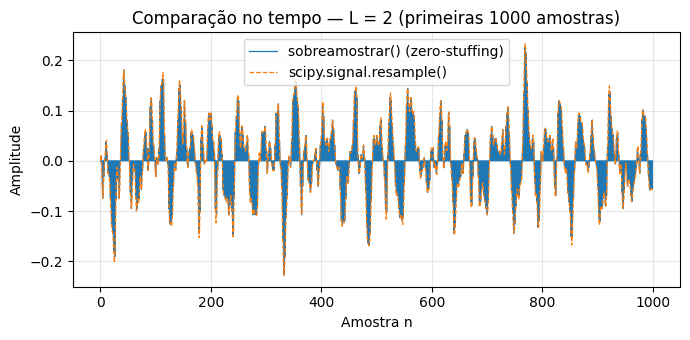

L = 2 — reproduzindo versão via resample():


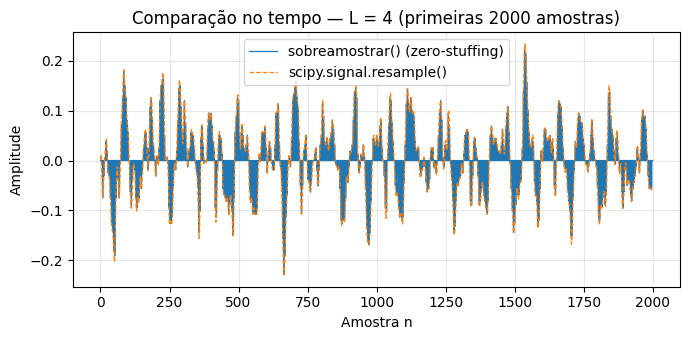

L = 4 — reproduzindo versão via resample():


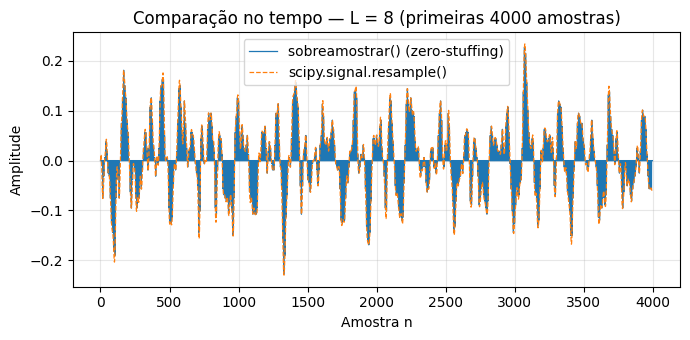

L = 8 — reproduzindo versão via resample():


In [ ]:
# Comparação no domínio do tempo: sobreamostragem própria (inserção de zeros,
# sem filtro) vs. scipy.signal.resample() (interpolação de banda limitada)
for L in FATORES_L:
    y_proprio, fs_novo = sinais_sobreamostrados[L]
    y_resample, _ = sinais_sobreamostrados_resample[L]

    n_janela = min(len(y_proprio), len(y_resample), 500 * L)
    plt.figure(figsize=(7, 3.5))
    plt.plot(y_proprio[:n_janela], label="sobreamostrar() (zero-stuffing)", linewidth=0.9)
    plt.plot(y_resample[:n_janela], label="scipy.signal.resample()", linewidth=0.9, linestyle="--")
    plt.xlabel("Amostra n")
    plt.ylabel("Amplitude")
    plt.title(f"Comparação no tempo — L = {L} (primeiras {n_janela} amostras)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"L = {L} — reproduzindo versão via resample():")
    tocar(y_resample, fs_novo)

## Questão 8 — Amostragem na frequência de Nyquist e reconstrução

x(t) = cos(2000πt) + sin(5000πt) = cos(2π·1000·t) + sin(2π·2500·t)

Componente de frequência mais alta: 2500 Hz → frequência de Nyquist
necessária: fs_nyquist = 2 × 2500 = 5000 Hz.


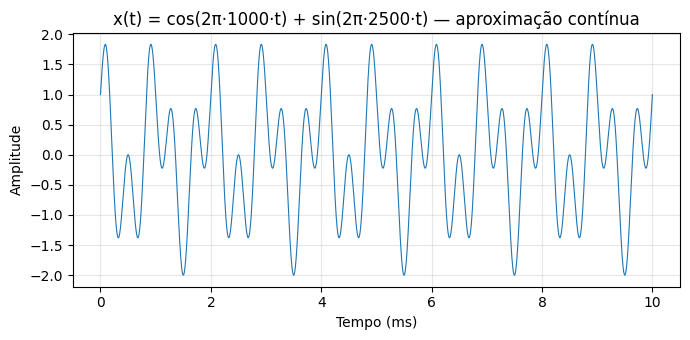

In [ ]:
# (a) x(t) "contínuo" (aproximado por fs muito alta) — 10 ms
FS_CONTINUO = 10e6  # 10 MHz
DURACAO_Q8 = 10e-3  # 10 ms

t_continuo = np.arange(0, DURACAO_Q8, 1 / FS_CONTINUO)
x_continuo = np.cos(2 * np.pi * 1000 * t_continuo) + np.sin(2 * np.pi * 2500 * t_continuo)

plotar_tempo(t_continuo * 1000, x_continuo,
             titulo="x(t) = cos(2π·1000·t) + sin(2π·2500·t) — aproximação contínua",
             xlabel="Tempo (ms)")

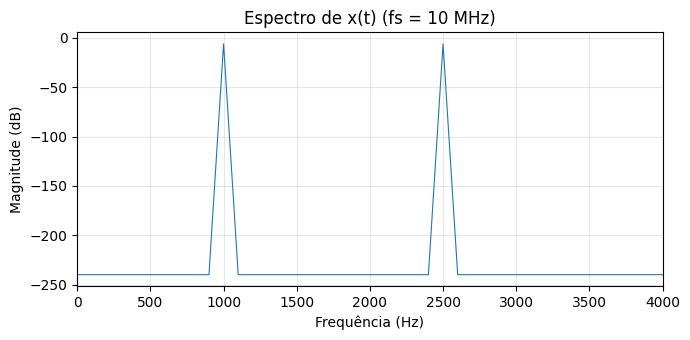

(array([0.0000e+00, 1.0000e+02, 2.0000e+02, ..., 4.9998e+06, 4.9999e+06,
        5.0000e+06]),
 array([1.47748480e-16, 1.48969156e-16, 1.53709970e-16, ...,
        5.08214650e-19, 1.72939137e-18, 2.22044605e-19]))

In [ ]:
# (b) espectro de x(t)
calculate_spectrum(x_continuo, FS_CONTINUO, titulo="Espectro de x(t) (fs = 10 MHz)", xlim=(0, 4000))

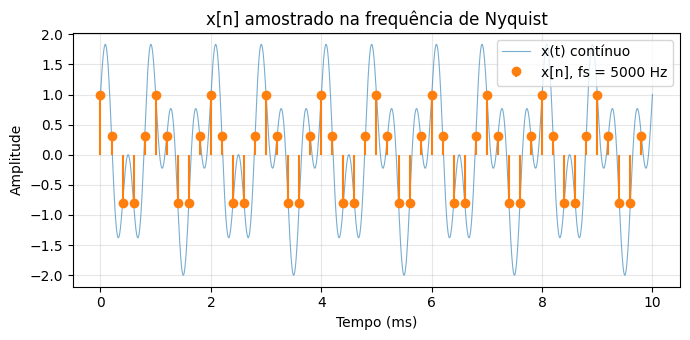

In [ ]:
# (c) amostragem de x(t) na frequência de Nyquist
F_MAX = 2500  # Hz — maior componente de frequência de x(t)
FS_NYQUIST = 2 * F_MAX  # 5000 Hz

t_amostrado = np.arange(0, DURACAO_Q8, 1 / FS_NYQUIST)
x_amostrado = np.cos(2 * np.pi * 1000 * t_amostrado) + np.sin(2 * np.pi * 2500 * t_amostrado)

plt.figure(figsize=(7, 3.5))
plt.plot(t_continuo * 1000, x_continuo, linewidth=0.8, label="x(t) contínuo", alpha=0.6)
plt.stem(t_amostrado * 1000, x_amostrado, linefmt="C1-", markerfmt="C1o", basefmt=" ",
         label=f"x[n], fs = {FS_NYQUIST} Hz")
plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude")
plt.title("x[n] amostrado na frequência de Nyquist")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

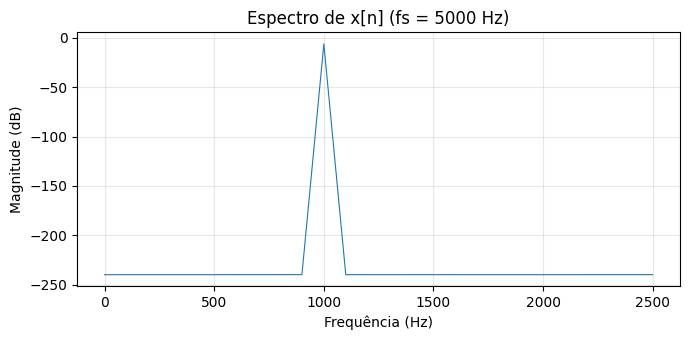

(array([   0.,  100.,  200.,  300.,  400.,  500.,  600.,  700.,  800.,
         900., 1000., 1100., 1200., 1300., 1400., 1500., 1600., 1700.,
        1800., 1900., 2000., 2100., 2200., 2300., 2400., 2500.]),
 array([6.39488462e-16, 4.23289410e-16, 2.15449957e-16, 1.97805163e-16,
        3.86895020e-16, 4.58529331e-16, 1.79240148e-15, 6.95525027e-16,
        2.84045630e-15, 1.45465726e-15, 5.00000000e-01, 1.02724043e-15,
        4.26032413e-16, 3.87017649e-16, 7.43714249e-16, 1.13796780e-15,
        6.59457037e-16, 3.37446736e-16, 2.45576584e-16, 4.29993882e-17,
        5.69529905e-16, 8.72775989e-16, 5.43644429e-16, 1.08210096e-15,
        1.05549784e-15, 3.74811293e-15]))

In [ ]:
# (d) espectro de x[n]
calculate_spectrum(x_amostrado, FS_NYQUIST, titulo=f"Espectro de x[n] (fs = {FS_NYQUIST} Hz)")

In [ ]:
# (e) reconstrução de x(t) a partir de x[n]

def reconstruir_sinc(x_n, fs_amostragem, t_alvo):
    """Reconstrução ideal por interpolação sinc:
    x(t) = sum_n x[n] * sinc(fs*(t - n/fs))
    """
    n = np.arange(len(x_n))
    t_amostras = n / fs_amostragem
    # matriz (len(t_alvo) x len(x_n)) — cada linha é sinc(fs*(t - n/fs)) para um t
    matriz = np.sinc(fs_amostragem * (t_alvo[:, None] - t_amostras[None, :]))
    return matriz @ x_n


def reconstruir_zoh(x_n, fs_amostragem, t_alvo):
    """Reconstrução por segurador de ordem zero (pulso retangular):
    mantém o valor da última amostra até a amostra seguinte.
    """
    indices = np.floor(t_alvo * fs_amostragem).astype(int)
    indices = np.clip(indices, 0, len(x_n) - 1)
    return x_n[indices]


x_reconstruido_sinc = reconstruir_sinc(x_amostrado, FS_NYQUIST, t_continuo)
x_reconstruido_zoh = reconstruir_zoh(x_amostrado, FS_NYQUIST, t_continuo)

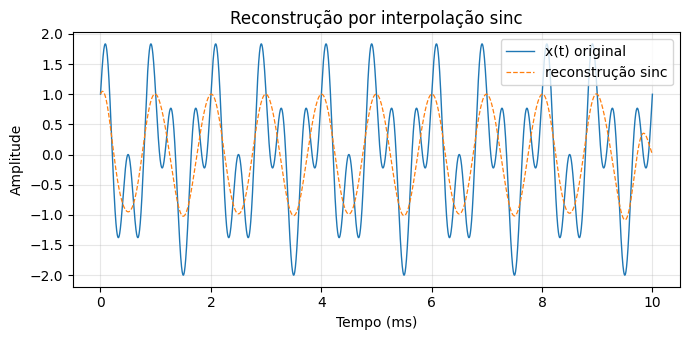

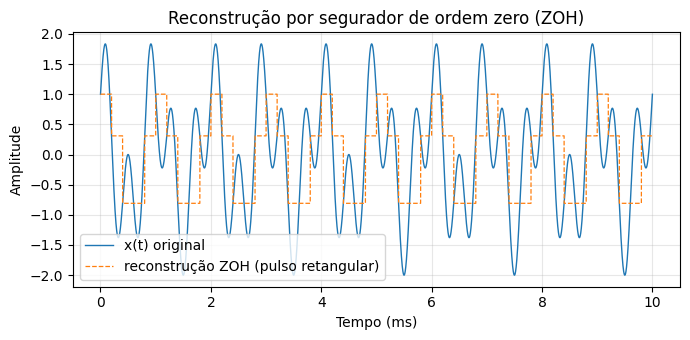

In [ ]:
plt.figure(figsize=(7, 3.5))
plt.plot(t_continuo * 1000, x_continuo, label="x(t) original", linewidth=1.0)
plt.plot(t_continuo * 1000, x_reconstruido_sinc, label="reconstrução sinc", linewidth=0.9, linestyle="--")
plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude")
plt.title("Reconstrução por interpolação sinc")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.5))
plt.plot(t_continuo * 1000, x_continuo, label="x(t) original", linewidth=1.0)
plt.plot(t_continuo * 1000, x_reconstruido_zoh, label="reconstrução ZOH (pulso retangular)", linewidth=0.9, linestyle="--")
plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude")
plt.title("Reconstrução por segurador de ordem zero (ZOH)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Questão 9 — Espectro de h_banheiro.wav e sinal_taca.wav


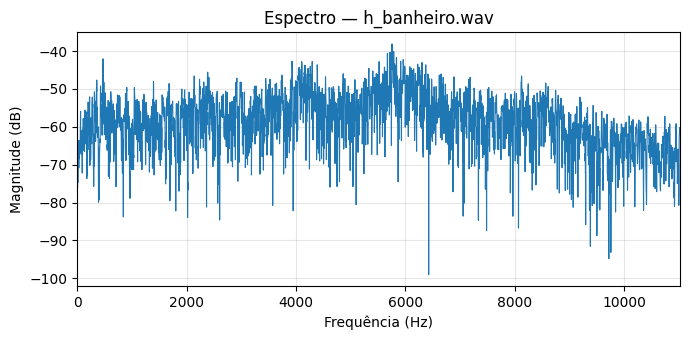

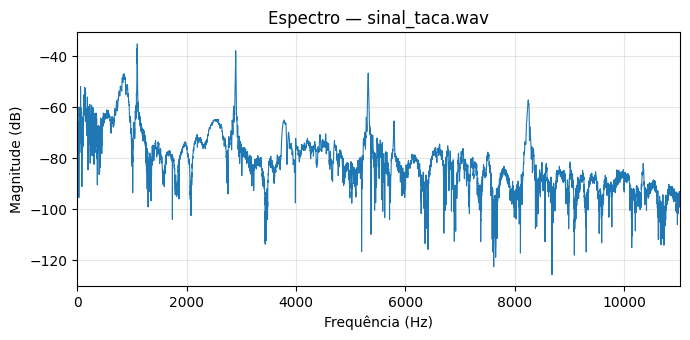

(array([0.00000000e+00, 1.15445026e+00, 2.30890052e+00, ...,
        1.10226911e+04, 1.10238455e+04, 1.10250000e+04]),
 array([5.29967499e-05, 2.75246017e-05, 5.46281578e-05, ...,
        1.42807331e-05, 1.64902677e-05, 1.54030592e-05]))

In [ ]:
fs_banheiro, h_banheiro = ler_wav("h_banheiro.wav")
fs_taca, sinal_taca = ler_wav("sinal_taca.wav")

calculate_spectrum(h_banheiro, fs_banheiro, titulo="Espectro — h_banheiro.wav", xlim=(0, fs_banheiro / 2))
calculate_spectrum(sinal_taca, fs_taca, titulo="Espectro — sinal_taca.wav", xlim=(0, fs_taca / 2))

## Questão 10 — Convolução com h_banheiro[n] e espectro das respostas

y[n] = x[n] * h_banheiro[n], para x[n] = handel.wav e x[n] = sinal_taca.wav.


In [ ]:
def igualar_fs(x, fs_x, fs_alvo):
    """Reamostra x de fs_x para fs_alvo (necessário para convoluir sinais
    com frequências de amostragem diferentes)."""
    if fs_x == fs_alvo:
        return x
    divisor = gcd(fs_x, fs_alvo)
    up, down = fs_alvo // divisor, fs_x // divisor
    return resample_poly(x, up, down)


def convoluir(x, fs_x, h, fs_h):
    h_rs = igualar_fs(h, fs_h, fs_x)
    y = fftconvolve(x, h_rs, mode="full")
    y = y / np.max(np.abs(y))
    return y, fs_x

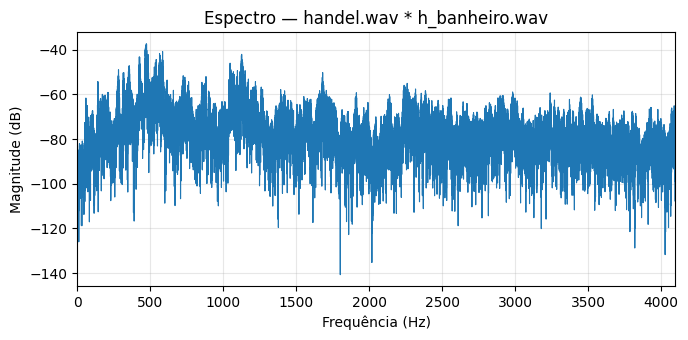

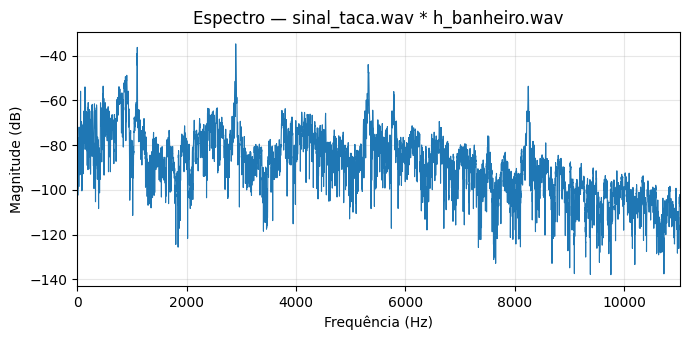

(array([0.00000000e+00, 7.71680549e-01, 1.54336110e+00, ...,
        1.10234566e+04, 1.10242283e+04, 1.10250000e+04]),
 array([1.14191160e-06, 2.90043757e-06, 2.58869282e-06, ...,
        4.65448725e-06, 5.76972004e-06, 4.65864062e-06]))

In [ ]:
y_audio, fs_y_audio = convoluir(x_handel, fs_handel, h_banheiro, fs_banheiro)
y_taca, fs_y_taca = convoluir(sinal_taca, fs_taca, h_banheiro, fs_banheiro)

calculate_spectrum(y_audio, fs_y_audio, titulo="Espectro — handel.wav * h_banheiro.wav", xlim=(0, fs_y_audio / 2))
calculate_spectrum(y_taca, fs_y_taca, titulo="Espectro — sinal_taca.wav * h_banheiro.wav", xlim=(0, fs_y_taca / 2))

In [ ]:
print("Resposta: handel.wav propagado no banheiro")
tocar(y_audio, fs_y_audio)

print("Resposta: sinal_taca.wav propagado no banheiro")
tocar(y_taca, fs_y_taca)

Resposta: handel.wav propagado no banheiro


Resposta: sinal_taca.wav propagado no banheiro
